In [1]:
import os
import sys

# agregar raiz del proyecto al path

# Obtener ruta raiz del proycto
project_root = os.path.abspath("..")

# Agregar raiz al path
sys.path.append(project_root)

print("Project Root : ", project_root)


Project Root :  C:\Users\Usuario\Desktop\proyectos\Global Earthquake History


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

from src.data_loader import load_data
from src.cleaning import clean_data, remove_incomplete_years
from src.forecasting import (
    earthquakes_per_year,
    train_arima_model,
    train_auto_arima,
    forecast_earthquakes
)

from src.prophet_model import (
    prepare_prophet_data,
    train_prophet_model,
    make_future_dataframe,
    generate_forecast
)

from src.visualization import plot_forecast

In [3]:
df_geh = load_data("../data/raw/earthquakes_1900_2026.csv")
df_geh = clean_data(df_geh)

df_geh.head()

✅ Dataset cargado correctamente

Filas : 1054683, Columnas : 23


,id,time,year,month,day_of_year,hour,latitude,longitude,depth,mag,...,tsunami,mag_category,depth_category,nst,gap,dmin,rms,net,updated,status
3,cent19000131192200000,1900-01-31 19:22:00+00:00,1900,1,31,19,48.00,146.00,450.0,7.50,...,0,Great (7-8),Deep (300-700km),NaN,NaN,NaN,NaN,cent,2025-04-26T21:47:57.256Z,reviewed
4,ushis388,1900-04-09 14:00:00+00:00,1900,4,99,14,41.37,-81.85,0.0,3.40,...,0,Light (3-4),Shallow (0-70km),NaN,NaN,NaN,NaN,ushis,2023-12-03T23:47:09.672Z,automatic
6,cent19000511172300000,1900-05-11 17:23:00+00:00,1900,5,131,17,38.70,141.10,5.0,7.00,...,0,Major (6-7),Shallow (0-70km),NaN,NaN,NaN,NaN,cent,2025-04-26T22:20:13.984Z,reviewed
11,official19001009122400000,1900-10-09 12:28:30+00:00,1900,10,282,12,57.40,-151.00,20.0,7.86,...,0,Great (7-8),Shallow (0-70km),NaN,NaN,NaN,NaN,official,2024-12-31T01:27:41.842Z,reviewed
15,cent19001124075700000,1900-11-24 07:57:00+00:00,1900,11,328,7,43.50,148.00,35.0,7.00,...,0,Major (6-7),Shallow (0-70km),NaN,NaN,NaN,NaN,cent,2025-04-23T23:45:17.013Z,reviewed


In [4]:
yearly_data = earthquakes_per_year(df_geh)
yearly_data.head()

,year,earthquake_count
0,1900,6
1,1901,5
2,1902,3
3,1903,2
4,1904,21


In [5]:
yearly_data_filtered = remove_incomplete_years(
    yearly_data,
    last_valid_year = 2025
)

yearly_data_filtered.tail()

,year,earthquake_count
121,2021,28693
122,2022,26640
123,2023,27108
124,2024,24900
125,2025,28981


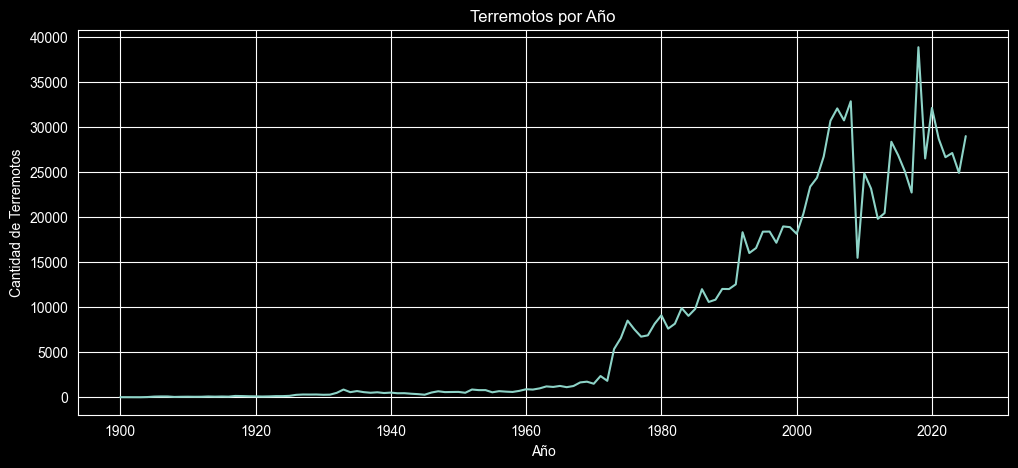

In [6]:
plt.figure(figsize = (12,5))
plt.plot(
    yearly_data_filtered["year"],
    yearly_data_filtered["earthquake_count"]
)
plt.title("Terremotos por Año")
plt.xlabel("Año")
plt.ylabel("Cantidad de Terremotos")
plt.show()

## Entrenar AUTO ARIMA

In [7]:
auto_model = train_auto_arima(
    yearly_data_filtered["earthquake_count"]
)

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.47 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=2355.732, Time=0.01 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=2321.497, Time=0.02 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=2320.938, Time=0.08 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=2354.508, Time=0.01 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=2320.637, Time=0.04 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=2321.636, Time=0.07 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=2320.812, Time=0.22 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=2319.810, Time=0.05 sec
 ARIMA(0,1,3)(0,0,0)[0] intercept   : AIC=2322.475, Time=0.06 sec
 ARIMA(1,1,3)(0,0,0)[0] intercept   : AIC=2322.192, Time=0.34 sec
 ARIMA(0,1,2)(0,0,0)[0]             : AIC=2319.195, Time=0.03 sec
 ARIMA(0,1,1)(0,0,0)[0]             : AIC=2322.759, Time=0.02 sec
 ARIMA(1,1,2)(0,0,0)[0]             : AIC=2321.069, Time=0.06 sec
 ARIMA(0,1,3)(0,0,0)[0]             : 

## Ver Resumen

In [8]:
print(auto_model.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  126
Model:               SARIMAX(0, 1, 2)   Log Likelihood               -1156.597
Date:                Wed, 27 May 2026   AIC                           2319.195
Time:                        20:53:20   BIC                           2327.680
Sample:                             0   HQIC                          2322.642
                                - 126                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.5935      0.065     -9.091      0.000      -0.721      -0.466
ma.L2          0.2929      0.086      3.422      0.001       0.125       0.461
sigma2       6.84e+06    2.9e+05     23.579      0.0

## Crear Serie Temporal

In [9]:
yearly_data_filtered = earthquakes_per_year(df_geh)
yearly_data_filtered.head()

,year,earthquake_count
0,1900,6
1,1901,5
2,1902,3
3,1903,2
4,1904,21


## Entrenar ARIMA

In [10]:
model = train_arima_model(
    yearly_data_filtered["earthquake_count"],
    order = (1, 1, 1)
)

print(model.summary())

                               SARIMAX Results                                
Dep. Variable:       earthquake_count   No. Observations:                  127
Model:                 ARIMA(1, 1, 1)   Log Likelihood               -1192.121
Date:                Wed, 27 May 2026   AIC                           2390.241
Time:                        20:53:42   BIC                           2398.750
Sample:                             0   HQIC                          2393.698
                                - 127                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.4354      0.243     -1.788      0.074      -0.913       0.042
ma.L1         -0.2008      0.220     -0.914      0.361      -0.631       0.230
sigma2      9.963e+06   5.97e+05     16.680      0.0

## Generar Forecast

In [11]:
forecast_auto = forecast_earthquakes(
    auto_model,
    steps = 10
)

forecast_auto

126    26503.268301
127    27483.528954
128    27483.528954
129    27483.528954
130    27483.528954
131    27483.528954
132    27483.528954
133    27483.528954
134    27483.528954
135    27483.528954
dtype: float64

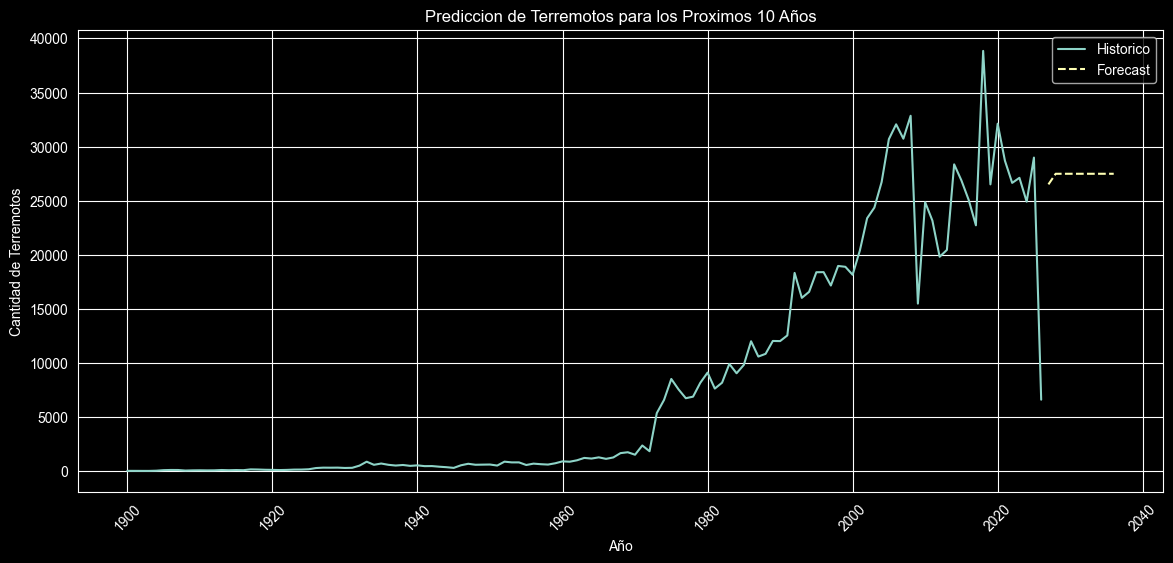

In [12]:
plot_forecast(yearly_data_filtered, forecast_auto)

## Crear DataFrame Futuro

In [13]:
# generar forecast correctamente

# Años futuros
future_years = list(
    range(
        yearly_data_filtered["year"].max() + 1,
        yearly_data_filtered["year"].max() + 11
    )
)

# DataFrame Forecast
forecast_df = pd.DataFrame({
    "year": future_years,
    "predicted_earthquakes" : forecast_auto
})

forecast_df

,year,predicted_earthquakes
126,2027,26503.268301
127,2028,27483.528954
128,2029,27483.528954
129,2030,27483.528954
130,2031,27483.528954
131,2032,27483.528954
132,2033,27483.528954
133,2034,27483.528954
134,2035,27483.528954
135,2036,27483.528954


## Exportar DataFrame

In [14]:
forecast_df.to_csv(
    "../reports/forecasts/arima_forecast.csv",
    index = False
)

print("✅ Forecast Exportado Correctamente")

✅ Forecast Exportado Correctamente


## Grafica

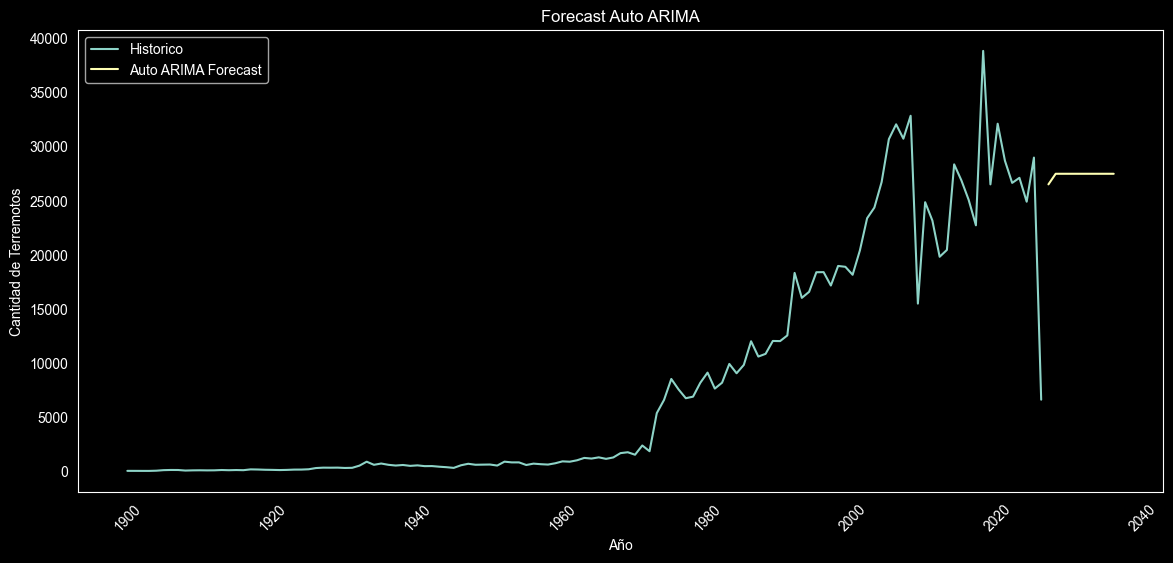

In [15]:
plt.figure(figsize = (14, 6))

# Historico
plt.plot(
    yearly_data_filtered["year"],
    yearly_data_filtered["earthquake_count"],
    label = "Historico"
)

# Forecast
plt.plot(
    forecast_df["year"],
    forecast_df["predicted_earthquakes"],
    linestyle = "-",
    label = "Auto ARIMA Forecast"
)

plt.title("Forecast Auto ARIMA")
plt.xlabel("Año")
plt.ylabel("Cantidad de Terremotos")
plt.xticks(rotation = 45)
plt.legend()
plt.grid()
plt.show()

In [16]:
yearly_data_filtered = remove_incomplete_years(
    yearly_data,
    last_valid_year = 2025
)

yearly_data_filtered.tail()

,year,earthquake_count
121,2021,28693
122,2022,26640
123,2023,27108
124,2024,24900
125,2025,28981


## Reentrenar Modelo

In [17]:
model_clean = train_arima_model(
    yearly_data_filtered["earthquake_count"],
    order = (1, 1, 1)
)

print(model_clean.summary())

                               SARIMAX Results                                
Dep. Variable:       earthquake_count   No. Observations:                  126
Model:                 ARIMA(1, 1, 1)   Log Likelihood               -1157.540
Date:                Wed, 27 May 2026   AIC                           2321.080
Time:                        20:54:13   BIC                           2329.565
Sample:                             0   HQIC                          2324.527
                                - 126                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.3210      0.238     -1.347      0.178      -0.788       0.146
ma.L1         -0.2432      0.225     -1.079      0.281      -0.685       0.199
sigma2      6.664e+06   3.16e+05     21.074      0.0

## Nuevo Forecast

In [18]:
forecast_clean = forecast_earthquakes(
    model_clean,
    steps = 10
)

forecast_clean

0          0.000000
1          3.296771
2          4.926266
3          4.109003
4          2.833694
           ...     
121    30125.704682
122    30139.045098
123    28149.745412
124    27211.101405
125    26170.635312
Name: predicted_mean, Length: 126, dtype: float64

## Nueva Grafica

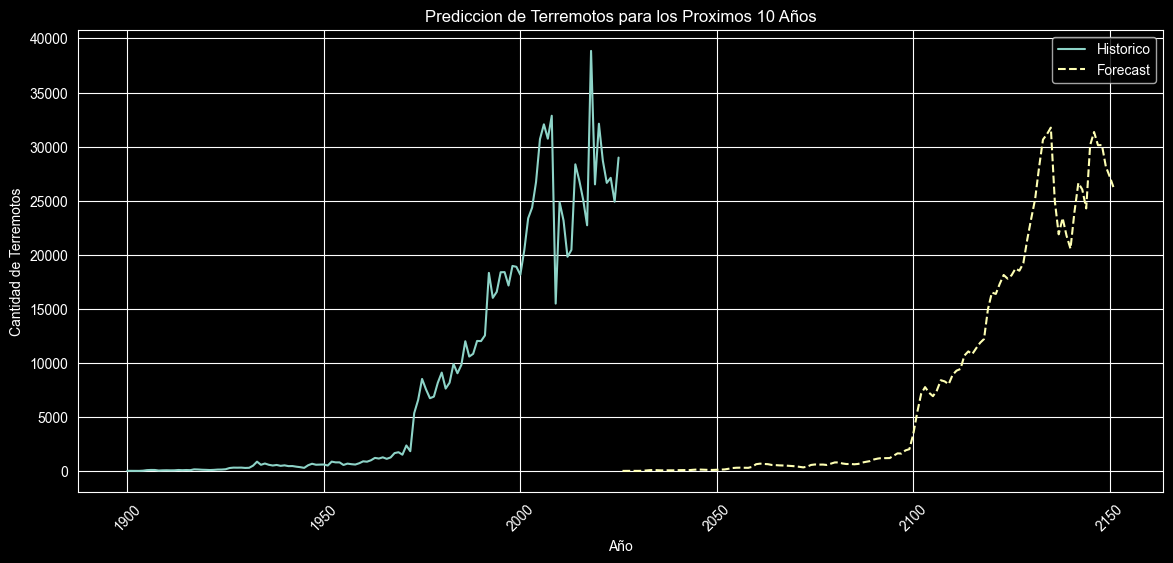

In [19]:
plot_forecast(
    yearly_data_filtered,
    forecast_clean
)

## Preparar Dataset para Prophet

In [20]:
prophet_df = prepare_prophet_data(yearly_data_filtered)

prophet_df.head()

,ds,y
0,1900-01-01,6
1,1901-01-01,5
2,1902-01-01,3
3,1903-01-01,2
4,1904-01-01,21


## Entrenar Modelo

In [21]:
prophet_model = train_prophet_model(prophet_df)

20:54:25 - cmdstanpy - INFO - Chain [1] start processing
20:54:27 - cmdstanpy - INFO - Chain [1] done processing


In [22]:
future_df = make_future_dataframe(prophet_model, periods = 10)
future_df.tail()

,ds
131,2030-12-31
132,2031-12-31
133,2032-12-31
134,2033-12-31
135,2034-12-31


## Forecast

In [24]:
forecast_prophet = generate_forecast(prophet_model, future_df)
forecast_prophet.tail()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
131,2030-12-31,35266.139550,31713.290957,38427.137580,35161.433494,35356.932501,-195.000211,-195.000211,-195.000211,-195.000211,-195.000211,-195.000211,0.0,0.0,0.0,35071.139339
132,2031-12-31,35767.960700,32392.477684,38859.619431,35632.804359,35890.428984,-75.198027,-75.198027,-75.198027,-75.198027,-75.198027,-75.198027,0.0,0.0,0.0,35692.762672
133,2032-12-31,36271.156702,32579.816255,39003.508692,36104.349757,36424.343472,-435.732125,-435.732125,-435.732125,-435.732125,-435.732125,-435.732125,0.0,0.0,0.0,35835.424577
134,2033-12-31,36772.977851,32911.816436,40115.876950,36575.751812,36957.766039,-315.226704,-315.226704,-315.226704,-315.226704,-315.226704,-315.226704,0.0,0.0,0.0,36457.751147
135,2034-12-31,37274.799000,33703.105304,40444.059390,37034.877833,37495.602021,-195.000211,-195.000211,-195.000211,-195.000211,-195.000211,-195.000211,0.0,0.0,0.0,37079.798790


## Visualizacion

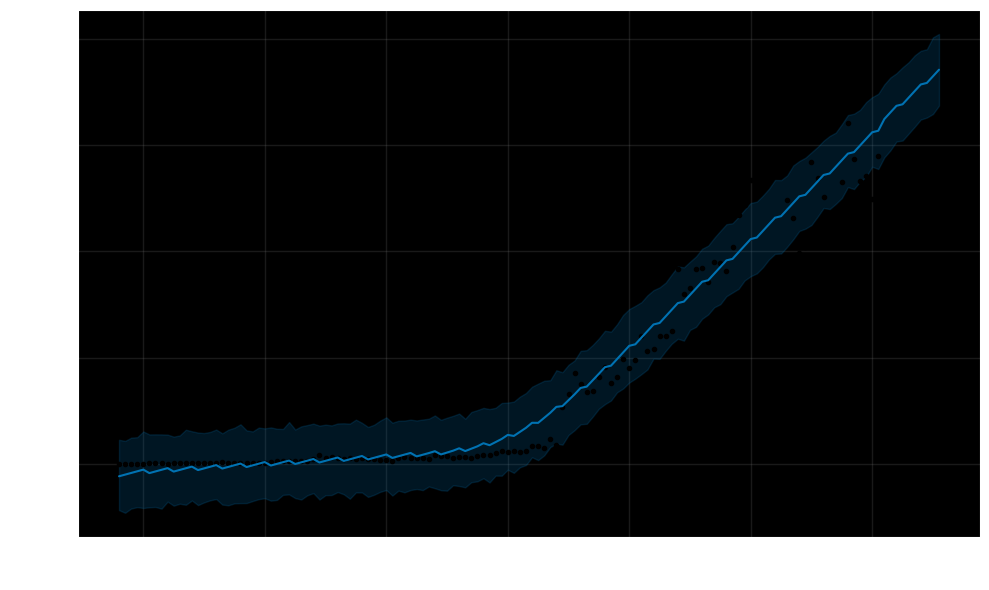

In [26]:
fig1 = prophet_model.plot(forecast_prophet)

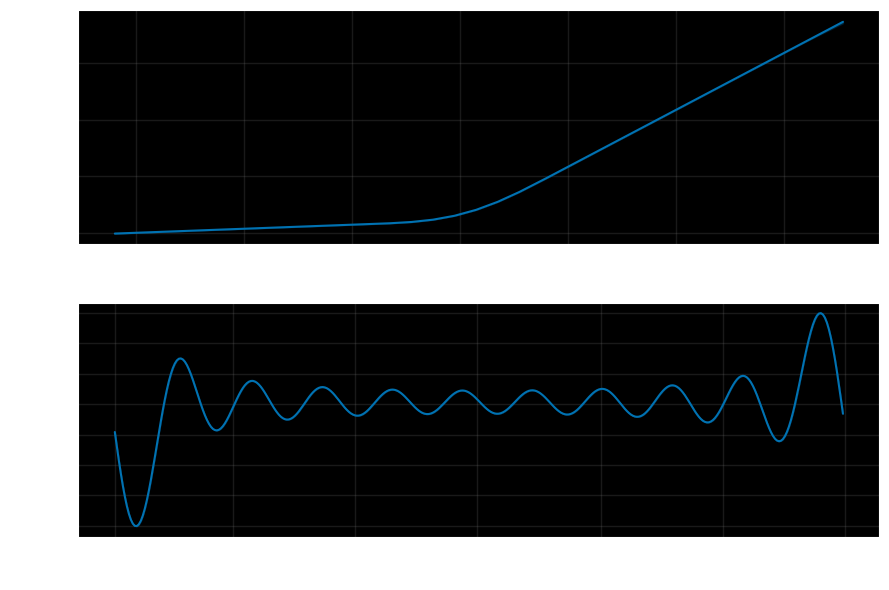

In [27]:
fig2 = prophet_model.plot_components(forecast_prophet)